# 00 — Data Preparation Pipeline

This notebook prepares all data for the avoidance-activation analysis pipeline (H1–H5). Run this notebook first before any hypothesis notebook.

## What this notebook does

1. **Loads and validates** the preprocessed data from Stage 5 of the main pipeline
2. **Applies exclusions** (calibration outliers: subjects 154, 197, 208)
3. **Computes vigor metrics** from raw keypress data:
   - Whole-trial: `median(1/IPI) / calibrationMax` → `trial_vigor.csv`
   - Pre/post-encounter epochs → `trial_vigor_epochs.csv`
4. **Reports data quality** — trial counts, missing data, distributions
5. **Produces analysis-ready files** that all downstream notebooks load

## Input files (from Stage 5 preprocessing)

| File | Contents | Rows |
|------|----------|------|
| `behavior.csv` | Choice trials only (type=1) | ~13,050 |
| `behavior_rich.csv` | All 81 trials per subject (choice + probes) | ~23,490 |
| `feelings.csv` | Probe ratings (anxiety + confidence) | ~10,546 |
| `psych.csv` | Psychiatric questionnaire scores | ~290 |

## Output files (produced by this notebook)

| File | Contents | Used by |
|------|----------|--------|
| `trial_vigor.csv` | Whole-trial vigor per trial | H1, H3 (model fitting) |
| `trial_vigor_epochs.csv` | Pre/post-encounter vigor per trial | H1, H2, H5 |

## Exclusions

Subjects 154, 197, 208 are excluded for calibration outliers (>2.5 SD on mean IPI). Applied consistently across all files. **N = 290 after exclusions.**

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import ast
import time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import zscore, pearsonr

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.right': False, 'axes.spines.top': False,
})

PROJECT_ROOT = Path('../..').resolve()
DATA_DIR = PROJECT_ROOT / 'data/exploratory_350/processed/stage5_filtered_data_20260320_191950'
EXCLUDE = [154, 197, 208]

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir: {DATA_DIR}')
print(f'Exclusions: {EXCLUDE}')

Project root: /Users/nokada/Documents/CALTECH/EffortForagingUnderThreat
Data dir: /Users/nokada/Documents/CALTECH/EffortForagingUnderThreat/data/exploratory_350/processed/stage5_filtered_data_20260320_191950
Exclusions: [154, 197, 208]


## Step 1: Load and validate source data

In [2]:
# ── Load all source files ──
beh = pd.read_csv(DATA_DIR / 'behavior.csv')
beh_rich = pd.read_csv(DATA_DIR / 'behavior_rich.csv', low_memory=False)
feelings = pd.read_csv(DATA_DIR / 'feelings.csv')
psych = pd.read_csv(DATA_DIR / 'psych.csv')

print('Source data loaded:')
print(f'  behavior.csv:      {len(beh):>6,} rows, {beh["subj"].nunique()} subjects')
print(f'  behavior_rich.csv: {len(beh_rich):>6,} rows, {beh_rich["subj"].nunique()} subjects')
print(f'  feelings.csv:      {len(feelings):>6,} rows, {feelings["subj"].nunique()} subjects')
print(f'  psych.csv:         {len(psych):>6,} rows, {psych["subj"].nunique()} subjects')

Source data loaded:
  behavior.csv:      13,185 rows, 293 subjects
  behavior_rich.csv: 23,733 rows, 293 subjects
  feelings.csv:      10,546 rows, 293 subjects
  psych.csv:            293 rows, 293 subjects


In [3]:
# ── Apply exclusions ──
beh = beh[~beh['subj'].isin(EXCLUDE)].copy()
beh_rich = beh_rich[~beh_rich['subj'].isin(EXCLUDE)].copy()
feelings = feelings[~feelings['subj'].isin(EXCLUDE)].copy()
psych = psych[~psych['subj'].isin(EXCLUDE)].copy()

N_subj = beh['subj'].nunique()
print(f'After exclusions ({EXCLUDE}):')
print(f'  N = {N_subj} subjects')
print(f'  Choice trials: {len(beh):,}')
print(f'  All trials: {len(beh_rich):,}')
print(f'  Probe ratings: {len(feelings):,}')
print(f'  Psych records: {len(psych)}')

After exclusions ([154, 197, 208]):
  N = 290 subjects
  Choice trials: 13,050
  All trials: 23,490
  Probe ratings: 10,438
  Psych records: 290


In [5]:
# ── Validate data structure ──
print('Data validation:')

# Trials per subject
trials_per_subj = beh_rich.groupby('subj').size()
print(f'  Trials per subject: min={trials_per_subj.min()}, max={trials_per_subj.max()}, '
      f'median={trials_per_subj.median():.0f}')

# Choice trials per subject
choice_per_subj = beh.groupby('subj').size()
print(f'  Choice trials per subject: min={choice_per_subj.min()}, max={choice_per_subj.max()}')

# Probe ratings per subject
probes_per_subj = feelings.groupby('subj').size()
print(f'  Probe ratings per subject: min={probes_per_subj.min()}, max={probes_per_subj.max()}')

# Threat and distance distributions
print(f'  Threat levels: {sorted(beh["threat"].round(1).unique())}')
print(f'  Distance levels: {sorted(beh["distance_H"].unique())}')

# Feelings question types
print(f'  Probe types: {feelings["questionLabel"].value_counts().to_dict()}')

# Psych columns
psych_measures = [c for c in psych.columns if c != 'subj' and not c.endswith('_RT')]
print(f'  Psych measures: {len(psych_measures)} ({psych_measures[:5]}...)')

# Subject overlap
subj_beh = set(beh['subj'].unique())
subj_rich = set(beh_rich['subj'].unique())
subj_feel = set(feelings['subj'].unique())
subj_psych = set(psych['subj'].unique())
common = subj_beh & subj_rich & subj_feel & subj_psych
print(f'  Subjects in ALL files: {len(common)}')
if len(common) < N_subj:
    missing = (subj_beh | subj_rich | subj_feel | subj_psych) - common
    print(f'  WARNING: {len(missing)} subjects not in all files: {missing}')

Data validation:
  Trials per subject: min=81, max=81, median=81
  Choice trials per subject: min=45, max=45
  Probe ratings per subject: min=35, max=36
  Threat levels: [np.float64(0.1), np.float64(0.5), np.float64(0.9)]
  Distance levels: [np.int64(1), np.int64(2), np.int64(3)]
  Probe types: {'anxiety': 5220, 'confidence': 5218}
  Psych measures: 18 (['participantID', 'DASS21_Stress', 'DASS21_Anxiety', 'DASS21_Depression', 'DASS21_Total']...)
  Subjects in ALL files: 290


## Step 2: Compute vigor metrics

### Vigor measure

**Normalized press rate** = `median(1/IPI) / calibrationMax`

where IPI is the inter-keypress interval from `alignedEffortRate` (keypress timestamps aligned to effort onset) and `calibrationMax` is each participant's maximum pressing speed from the calibration phase.

This metric:
- Is on a common scale across participants (fraction of individual capacity)
- Uses the median (robust to outlier keypresses)
- Filters IPIs > 10ms (removes double-counted keypresses)
- Requires at least 5 valid IPIs per trial

### Epoch decomposition

For analyses of vigor dynamics (H2, H5), we also compute separate press rates for:
- **Pre-encounter**: keypresses before `encounterTime`
- **Post-encounter**: keypresses from `encounterTime` to `encounterTime + 2s`

In [6]:
def compute_median_rate(effort_rate_str, calibration_max):
    """Compute median(1/IPI) / calibrationMax from alignedEffortRate string."""
    try:
        pt = np.array(ast.literal_eval(str(effort_rate_str)), dtype=float)
        ipis = np.diff(pt)
        ipis = ipis[ipis > 0.01]
        if len(ipis) >= 5 and calibration_max > 0:
            return np.median(1.0 / ipis) / calibration_max
        return np.nan
    except Exception:
        return np.nan


def compute_epoch_rates(effort_rate_str, calibration_max, encounter_time):
    """Compute median(1/IPI)/cal for pre-encounter and post-encounter epochs."""
    try:
        pt = np.array(ast.literal_eval(str(effort_rate_str)), dtype=float)
        cal = calibration_max
        enc_t = float(encounter_time) if pd.notna(encounter_time) else np.nan

        if len(pt) < 5 or cal <= 0 or np.isnan(enc_t):
            return np.nan, np.nan

        def rate_from_pts(pts):
            if len(pts) < 4:
                return np.nan
            ipis = np.diff(pts)
            ipis = ipis[ipis > 0.01]
            if len(ipis) < 3:
                return np.nan
            return np.median(1.0 / ipis) / cal

        pre = rate_from_pts(pt[pt < enc_t])
        post = rate_from_pts(pt[(pt >= enc_t) & (pt < enc_t + 2.0)])
        return pre, post
    except Exception:
        return np.nan, np.nan

In [7]:
# ── Check if vigor files already exist ──
vigor_path = DATA_DIR / 'trial_vigor.csv'
epochs_path = DATA_DIR / 'trial_vigor_epochs.csv'

if vigor_path.exists() and epochs_path.exists():
    print('Vigor files already exist. Loading...')
    trial_vigor = pd.read_csv(vigor_path)
    trial_epochs = pd.read_csv(epochs_path)
    print(f'  trial_vigor.csv: {len(trial_vigor):,} rows')
    print(f'  trial_vigor_epochs.csv: {len(trial_epochs):,} rows')
    RECOMPUTE = False
else:
    print('Vigor files not found. Computing from scratch...')
    RECOMPUTE = True

if RECOMPUTE:
    t0 = time.time()

    # ── Whole-trial vigor ──
    print('Computing whole-trial vigor...')
    beh_rich['median_rate'] = beh_rich.apply(
        lambda row: compute_median_rate(row['alignedEffortRate'], row['calibrationMax']),
        axis=1
    )

    # ── Epoch vigor ──
    print('Computing epoch vigor (pre/post encounter)...')
    epoch_results = beh_rich.apply(
        lambda row: compute_epoch_rates(
            row['alignedEffortRate'], row['calibrationMax'], row['encounterTime']
        ), axis=1, result_type='expand'
    )
    beh_rich['pre_enc_rate'] = epoch_results[0]
    beh_rich['post_enc_rate'] = epoch_results[1]

    # ── Derived columns ──
    beh_rich['actual_req'] = np.where(beh_rich['trialCookie_weight'] == 3.0, 0.9, 0.4)
    beh_rich['excess'] = beh_rich['median_rate'] - beh_rich['actual_req']
    beh_rich['actual_dist'] = beh_rich['startDistance'].map({5: 1, 7: 2, 9: 3})
    beh_rich['actual_R'] = np.where(beh_rich['trialCookie_weight'] == 3.0, 5.0, 1.0)
    beh_rich['is_heavy'] = (beh_rich['trialCookie_weight'] == 3.0).astype(int)

    # ── Save whole-trial vigor ──
    vigor_cols = ['subj', 'trial', 'type', 'threat', 'startDistance', 'actual_dist',
                  'distance_H', 'trialCookie_weight', 'calibrationMax',
                  'median_rate', 'actual_req', 'actual_R', 'is_heavy', 'excess']
    trial_vigor = beh_rich[vigor_cols].copy()
    trial_vigor.to_csv(vigor_path, index=False)

    # ── Save epoch vigor ──
    epoch_cols = ['subj', 'trial', 'type', 'threat', 'startDistance', 'distance_H',
                  'trialCookie_weight', 'calibrationMax', 'pre_enc_rate', 'post_enc_rate',
                  'isAttackTrial', 'encounterTime', 'actual_dist', 'actual_req',
                  'actual_R', 'is_heavy']
    trial_epochs = beh_rich[epoch_cols].copy()
    trial_epochs.to_csv(epochs_path, index=False)

    elapsed = time.time() - t0
    print(f'Done in {elapsed:.0f}s')
    print(f'  Saved {vigor_path.name} ({vigor_path.stat().st_size / 1e6:.1f} MB)')
    print(f'  Saved {epochs_path.name} ({epochs_path.stat().st_size / 1e6:.1f} MB)')

Vigor files already exist. Loading...
  trial_vigor.csv: 23,490 rows
  trial_vigor_epochs.csv: 23,490 rows


## Step 3: Data quality report

In [8]:
# ── Vigor data quality ──
print('VIGOR DATA QUALITY')
print('=' * 50)

valid_whole = trial_vigor['median_rate'].notna().sum()
missing_whole = trial_vigor['median_rate'].isna().sum()
print(f'Whole-trial vigor:')
print(f'  Valid: {valid_whole:,} ({valid_whole/len(trial_vigor):.1%})')
print(f'  Missing: {missing_whole:,} ({missing_whole/len(trial_vigor):.1%})')

valid_pre = trial_epochs['pre_enc_rate'].notna().sum()
valid_post = trial_epochs['post_enc_rate'].notna().sum()
print(f'\nPre-encounter vigor:')
print(f'  Valid: {valid_pre:,} ({valid_pre/len(trial_epochs):.1%})')
print(f'Post-encounter vigor:')
print(f'  Valid: {valid_post:,} ({valid_post/len(trial_epochs):.1%})')

# Per-subject completeness
subj_valid = trial_vigor.groupby('subj')['median_rate'].apply(lambda x: x.notna().sum())
print(f'\nTrials with valid vigor per subject:')
print(f'  min={subj_valid.min()}, max={subj_valid.max()}, median={subj_valid.median():.0f}')
low_trial_subj = (subj_valid < 30).sum()
if low_trial_subj > 0:
    print(f'  WARNING: {low_trial_subj} subjects have < 30 valid vigor trials')

VIGOR DATA QUALITY
Whole-trial vigor:
  Valid: 23,132 (98.5%)
  Missing: 358 (1.5%)

Pre-encounter vigor:
  Valid: 18,050 (76.8%)
Post-encounter vigor:
  Valid: 22,355 (95.2%)

Trials with valid vigor per subject:
  min=59, max=81, median=81


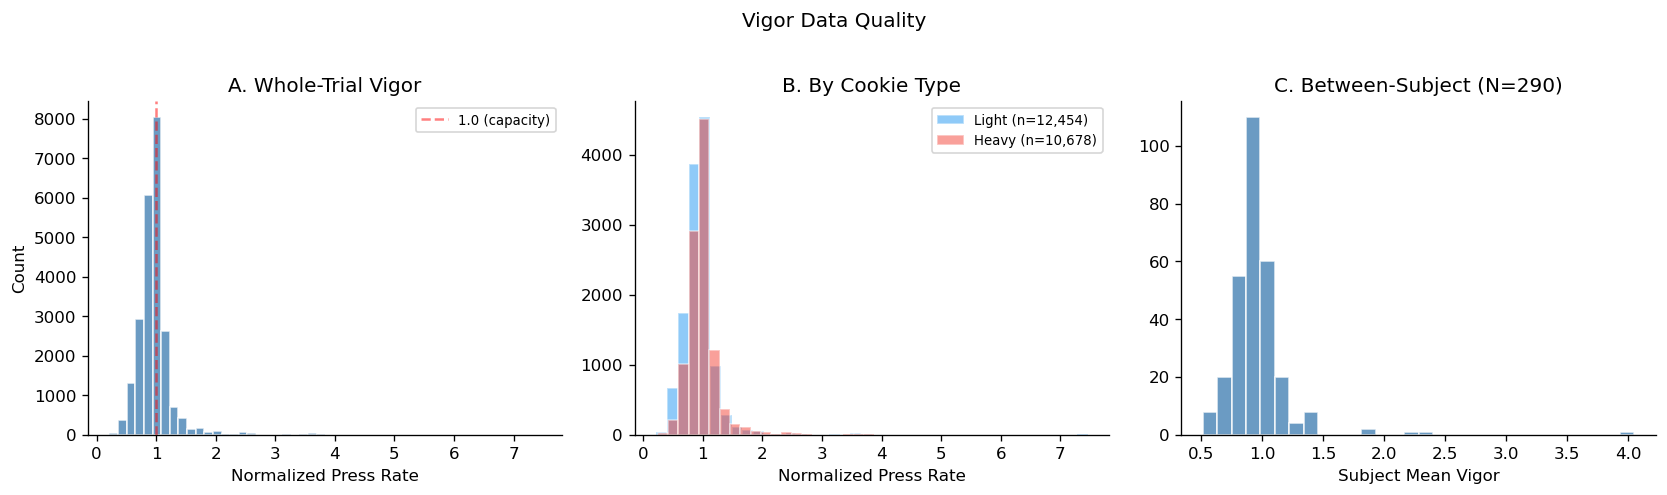

Vigor summary: mean=0.965, SD=0.300, range=[0.216, 7.457]


In [9]:
# ── Vigor distributions ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

valid = trial_vigor.dropna(subset=['median_rate'])

# Panel A: Whole-trial vigor distribution
ax = axes[0]
ax.hist(valid['median_rate'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(1.0, color='red', ls='--', alpha=0.5, label='1.0 (capacity)')
ax.set_xlabel('Normalized Press Rate')
ax.set_ylabel('Count')
ax.set_title('A. Whole-Trial Vigor')
ax.legend(fontsize=8)

# Panel B: By cookie type
ax = axes[1]
for cookie, label, color in [(0, 'Light', '#2196F3'), (1, 'Heavy', '#F44336')]:
    sub = valid[valid['is_heavy'] == cookie]
    ax.hist(sub['median_rate'], bins=40, color=color, edgecolor='white',
            alpha=0.5, label=f'{label} (n={len(sub):,})')
ax.set_xlabel('Normalized Press Rate')
ax.set_title('B. By Cookie Type')
ax.legend(fontsize=8)

# Panel C: Per-subject means
ax = axes[2]
subj_means = valid.groupby('subj')['median_rate'].mean()
ax.hist(subj_means, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Subject Mean Vigor')
ax.set_title(f'C. Between-Subject (N={len(subj_means)})')

plt.suptitle('Vigor Data Quality', y=1.02)
plt.tight_layout()
plt.show()

print(f'Vigor summary: mean={valid["median_rate"].mean():.3f}, '
      f'SD={valid["median_rate"].std():.3f}, '
      f'range=[{valid["median_rate"].min():.3f}, {valid["median_rate"].max():.3f}]')

In [10]:
# ── Affect data quality ──
print('AFFECT DATA QUALITY')
print('=' * 50)

anx = feelings[feelings['questionLabel'] == 'anxiety']
con = feelings[feelings['questionLabel'] == 'confidence']

print(f'Anxiety ratings: {len(anx):,} ({anx["subj"].nunique()} subjects)')
print(f'  per subject: min={anx.groupby("subj").size().min()}, '
      f'max={anx.groupby("subj").size().max()}')
print(f'  response range: [{anx["response"].min()}, {anx["response"].max()}]')
print(f'  mean={anx["response"].mean():.2f}, SD={anx["response"].std():.2f}')

print(f'\nConfidence ratings: {len(con):,} ({con["subj"].nunique()} subjects)')
print(f'  per subject: min={con.groupby("subj").size().min()}, '
      f'max={con.groupby("subj").size().max()}')
print(f'  response range: [{con["response"].min()}, {con["response"].max()}]')
print(f'  mean={con["response"].mean():.2f}, SD={con["response"].std():.2f}')

AFFECT DATA QUALITY
Anxiety ratings: 5,220 (290 subjects)
  per subject: min=18, max=18
  response range: [0, 7]
  mean=4.40, SD=2.24

Confidence ratings: 5,218 (290 subjects)
  per subject: min=17, max=18
  response range: [0, 7]
  mean=3.17, SD=2.28


In [14]:
# ── Psychiatric data quality ──
print('PSYCHIATRIC DATA QUALITY')
print('=' * 50)

psych_cols = [c for c in psych.columns if c != 'subj' and not c.endswith('_RT')]
missing = psych[psych_cols].isna().sum()
if missing.sum() > 0:
    print('Missing values:')
    for col in psych_cols:
        n_miss = psych[col].isna().sum()
        if n_miss > 0:
            print(f'  {col}: {n_miss} missing ({n_miss/len(psych):.1%})')
else:
    print('No missing values in psychiatric measures.')

print(f'\nMeasure summary:')
for col in psych_cols[:10]:
    vals = psych[col].dropna()
    print(f'  {col:25s}: mean={vals.mean():>6.1f}, SD={vals.std():>5.1f}, '
          f'range=[{vals.min():.0f}, {vals.max():.0f}]')

PSYCHIATRIC DATA QUALITY
Missing values:
  MFIS_Physical: 1 missing (0.3%)
  MFIS_Cognitive: 1 missing (0.3%)
  MFIS_Psychosocial: 1 missing (0.3%)
  MFIS_Total: 1 missing (0.3%)
  STAI_Trait: 1 missing (0.3%)

Measure summary:


TypeError: Cannot perform reduction 'mean' with string dtype

## Step 4: Cookie normalization

For analyses that compare vigor across conditions (H1c, H2, H5), we normalize each trial's vigor by the subject's mean vigor for that cookie type. This removes the mechanical demand difference between heavy (req=0.9) and light (req=0.4) cookies.

`vigor_norm = pre_enc_rate / mean(pre_enc_rate for this subject × cookie type)`

A value of 1.0 means pressing at your typical rate for this cookie. >1.0 = ramping up. <1.0 = coasting.

In [13]:
# ── Demonstrate cookie normalization ──
epochs_valid = trial_epochs.dropna(subset=['pre_enc_rate']).copy()

# Cookie-normalize
subj_cookie_mean = epochs_valid.groupby(['subj', 'is_heavy'])['pre_enc_rate'].transform('mean')
epochs_valid['vigor_norm'] = epochs_valid['pre_enc_rate'] / subj_cookie_mean

print('Cookie normalization check:')
print(f'  Raw pre-enc rate by cookie:')
for cookie, name in [(0, 'Light'), (1, 'Heavy')]:
    v = epochs_valid[epochs_valid['is_heavy'] == cookie]['pre_enc_rate'].mean()
    print(f'    {name}: {v:.4f}')

print(f'  Normalized by cookie (should both be ~1.0):')
for cookie, name in [(0, 'Light'), (1, 'Heavy')]:
    v = epochs_valid[epochs_valid['is_heavy'] == cookie]['vigor_norm'].mean()
    print(f'    {name}: {v:.4f}')

print(f'\n  Normalized vigor by threat:')
epochs_valid['T_round'] = epochs_valid['threat'].round(1)
for T in [0.1, 0.5, 0.9]:
    v = epochs_valid[epochs_valid['T_round'] == T]['vigor_norm'].mean()
    print(f'    T={T}: {v:.4f}')

print(f'\n  Cookie normalization removes the demand confound.')
print(f'  The threat effect is now visible without conditioning on cookie type.')

Cookie normalization check:
  Raw pre-enc rate by cookie:
    Light: 0.9449
    Heavy: 1.0152
  Normalized by cookie (should both be ~1.0):
    Light: 1.0000
    Heavy: 1.0000

  Normalized vigor by threat:
    T=0.1: 0.9900
    T=0.5: 0.9994
    T=0.9: 1.0110

  Cookie normalization removes the demand confound.
  The threat effect is now visible without conditioning on cookie type.


## Summary

### Files ready for analysis

| File | Location | Description |
|------|----------|-------------|
| `behavior.csv` | DATA_DIR | Choice trials (type=1 only) |
| `behavior_rich.csv` | DATA_DIR | All trials (choice + probes) |
| `feelings.csv` | DATA_DIR | Probe ratings (questionLabel = 'anxiety' or 'confidence') |
| `psych.csv` | DATA_DIR | Psychiatric measures |
| `trial_vigor.csv` | DATA_DIR | Whole-trial vigor (median_rate per trial) |
| `trial_vigor_epochs.csv` | DATA_DIR | Pre/post-encounter vigor (pre_enc_rate, post_enc_rate) |

### Key processing decisions

1. **Vigor metric:** `median(1/IPI) / calibrationMax` — capacity-normalized, robust to outlier keypresses
2. **Exclusions:** Subjects 154, 197, 208 (calibration outliers > 2.5 SD on mean IPI)
3. **Cookie normalization:** `vigor / subject-cookie-mean` removes demand confound for cross-condition comparisons
4. **Pre-encounter epoch:** Keypresses before `encounterTime` — captures deliberative vigor without reactive contamination
5. **Environmental distance:** `distance_H` (offered heavy-cookie distance) for vigor slope analyses, not `actual_dist` (chosen cookie distance)

### Proceed to

- `H1_adaptive_shifts.ipynb` — Behavioral effects of threat on choice, vigor, affect
- `H2_vigor_dynamics.ipynb` — Vigor across the predatory imminence continuum
- `H3_model_comparison.ipynb` — Five-model comparison (requires model fitting first)
- `H4_profiles_optimality.ipynb` — Foraging profiles in parameter space (requires H3 params)
- `H5_metacognitive.ipynb` — Metacognitive monitoring of the foraging computation